In [228]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

In [229]:
weather_data = (pd.read_csv("./dataset/Weather_Data.csv"))[["Sunshine", "Evaporation"]]

In [230]:
weather_data = weather_data.head(100)

# Part 1 : Descriptive Statistics

## Part 1.1 : Dispersion

In [231]:
weather_data.describe()

,Sunshine,Evaporation
count,100.000,100.000000
mean,7.073,4.863000
std,3.763,1.906748
min,0.000,1.200000
25%,3.300,3.400000
50%,8.500,4.600000
75%,10.325,6.400000
max,12.200,10.600000


In [232]:
# Create new dataset with intermediate calculation columns
new_data = weather_data.copy()
new_data['Observation'] = range(1, len(new_data) + 1)

# Compute means
mean_sunshine = new_data['Sunshine'].mean()
mean_evaporation = new_data['Evaporation'].mean()

# Add deviation and power columns for Sunshine
new_data['Sunshine - Mean_S'] = new_data['Sunshine'] - mean_sunshine
new_data['(Sunshine - Mean_S)^2'] = new_data['Sunshine - Mean_S'] ** 2

# Add deviation and power columns for Evaporation
new_data['Evaporation - Mean_E'] = new_data['Evaporation'] - mean_evaporation
new_data['(Evaporation - Mean_E)^2'] = new_data['Evaporation - Mean_E'] ** 2

In [233]:
# Create separate tables for Sunshine and Evaporation
sunshine_data = new_data[['Observation', 'Sunshine', 'Sunshine - Mean_S', '(Sunshine - Mean_S)^2']].copy()
evaporation_data = new_data[['Observation', 'Evaporation', 'Evaporation - Mean_E', '(Evaporation - Mean_E)^2']].copy()

# Display the Sunshine table
print("Sunshine Data Table:")
sunshine_data.head()

Sunshine Data Table:


,Observation,Sunshine,Sunshine - Mean_S,(Sunshine - Mean_S)^2
0,1,0.0,-7.073,50.027329
1,2,2.7,-4.373,19.123129
2,3,0.1,-6.973,48.622729
3,4,0.0,-7.073,50.027329
4,5,0.0,-7.073,50.027329


In [234]:
# Display the Evaporation table
print("Evaporation Data Table:")
evaporation_data.head()

Evaporation Data Table:


,Observation,Evaporation,Evaporation - Mean_E,(Evaporation - Mean_E)^2
0,1,6.2,1.337,1.787569
1,2,3.4,-1.463,2.140369
2,3,2.4,-2.463,6.066369
3,4,2.2,-2.663,7.091569
4,5,4.8,-0.063,0.003969


In [235]:
import numpy as np

# Add class interval to Sunshine data table
min_s = sunshine_data['Sunshine'].min()
max_s = sunshine_data['Sunshine'].max()
bin_width = 3
# Calculate number of bins needed to cover all data
num_bins = int(np.ceil((max_s - min_s) / bin_width))
# Create bins starting from a value slightly below min to include all points
bin_start = np.floor(min_s / bin_width) * bin_width
bins_s = [bin_start + i * bin_width for i in range(num_bins + 1)]
sunshine_data['Class Interval'] = pd.cut(sunshine_data['Sunshine'], bins=bins_s, right=False)

# Create Evaporation Frequency Distribution Table
freq_s = sunshine_data["Class Interval"].value_counts().sort_index()
# Store original intervals for midpoint calculation
original_intervals_s = freq_s.index

sunshine_freq_table = pd.DataFrame({
    'Class Interval': [f"{interval.left} - {interval.right}" for interval in freq_s.index],
    'Frequency': freq_s.values
})

# Add extra columns
sunshine_freq_table["Mid of the interval (x)"] = [
    (interval.left + interval.right) / 2 for interval in original_intervals_s
]
# Use mid of modal class as assumed mean
modal_mid_s = sunshine_freq_table.loc[sunshine_freq_table['Frequency'].idxmax(), 'Mid of the interval (x)']
assumed_mean_s = modal_mid_s
h = 3
sunshine_freq_table['Deviation (d)'] = (sunshine_freq_table['Mid of the interval (x)'] - assumed_mean_s) / h
sunshine_freq_table['Deviation * Frequency'] = sunshine_freq_table['Deviation (d)'] * sunshine_freq_table['Frequency']
sunshine_freq_table['Deviation^2 * Frequency'] = sunshine_freq_table['Deviation (d)'] ** 2 * sunshine_freq_table['Frequency']

# Add totals row
total_freq_s = sunshine_freq_table['Frequency'].sum()
mean_from_grouped_s = assumed_mean_s + (sunshine_freq_table['Deviation * Frequency'].sum() / total_freq_s) * h
totals_s = pd.Series({
    'Class Interval': 'Total',
    'Frequency': total_freq_s,
    'Mid of the interval (x)': np.nan,
    'Deviation (d)': np.nan,
    'Deviation * Frequency': sunshine_freq_table['Deviation * Frequency'].sum(),
    'Deviation^2 * Frequency': sunshine_freq_table['Deviation^2 * Frequency'].sum()
})
sunshine_freq_table = pd.concat([sunshine_freq_table, pd.DataFrame([totals_s])], ignore_index=True)

# Display Sunshine Frequency Table
print("Sunshine Frequency Distribution Table:")
sunshine_freq_table

Sunshine Frequency Distribution Table:


,Class Interval,Frequency,Mid of the interval (x),Deviation (d),Deviation * Frequency,Deviation^2 * Frequency
0,0.0 - 3.0,21,1.5,-3.0,-63.0,189.0
1,3.0 - 6.0,14,4.5,-2.0,-28.0,56.0
2,6.0 - 9.0,22,7.5,-1.0,-22.0,22.0
3,9.0 - 12.0,41,10.5,0.0,0.0,0.0
4,12.0 - 15.0,2,13.5,1.0,2.0,2.0
5,Total,100,NaN,NaN,-111.0,269.0


In [236]:
# Add class interval to Evaporation data table
min_e = evaporation_data['Evaporation'].min()
max_e = evaporation_data['Evaporation'].max()
# Calculate number of bins needed to cover all data
num_bins_e = int(np.ceil((max_e - min_e) / bin_width))
# Create bins starting from a value slightly below min to include all points
bin_start_e = np.floor(min_e / bin_width) * bin_width
bins_e = [bin_start_e + i * bin_width for i in range(num_bins_e + 1)]
evaporation_data['Class Interval'] = pd.cut(evaporation_data['Evaporation'], bins=bins_e, right=False)

# Create Evaporation Frequency Distribution Table
freq_e = evaporation_data['Class Interval'].value_counts().sort_index()
# Store original intervals for midpoint calculation
original_intervals_e = freq_e.index

evaporation_freq_table = pd.DataFrame({
    'Class Interval': [f"{interval.left} - {interval.right}" for interval in freq_e.index],
    'Frequency': freq_e.values
})

# Add extra columns
evaporation_freq_table['Mid of the interval (x)'] = [(interval.left + interval.right) / 2 for interval in original_intervals_e]
# Use mid of modal class as assumed mean
modal_mid_e = evaporation_freq_table.loc[evaporation_freq_table['Frequency'].idxmax(), 'Mid of the interval (x)']
assumed_mean_e = modal_mid_e
evaporation_freq_table['Deviation (d)'] = (evaporation_freq_table['Mid of the interval (x)'] - assumed_mean_e) / h
evaporation_freq_table['Deviation * Frequency'] = evaporation_freq_table['Deviation (d)'] * evaporation_freq_table['Frequency']
evaporation_freq_table['Deviation^2 * Frequency'] = evaporation_freq_table['Deviation (d)'] ** 2 * evaporation_freq_table['Frequency']

# Add totals row
total_freq_e = evaporation_freq_table['Frequency'].sum()
mean_from_grouped_e = assumed_mean_e + (evaporation_freq_table['Deviation * Frequency'].sum() / total_freq_e) * h
totals_e = pd.Series({
    'Class Interval': 'Total',
    'Frequency': total_freq_e,
    'Mid of the interval (x)': np.nan,
    'Deviation (d)': np.nan,
    'Deviation * Frequency': evaporation_freq_table['Deviation * Frequency'].sum(),
    'Deviation^2 * Frequency': evaporation_freq_table['Deviation^2 * Frequency'].sum()
})
evaporation_freq_table = pd.concat([evaporation_freq_table, pd.DataFrame([totals_e])], ignore_index=True)

# Display Evaporation Frequency Table
print("Evaporation Frequency Distribution Table:")
evaporation_freq_table

Evaporation Frequency Distribution Table:


,Class Interval,Frequency,Mid of the interval (x),Deviation (d),Deviation * Frequency,Deviation^2 * Frequency
0,0.0 - 3.0,16,1.5,-1.0,-16.0,16.0
1,3.0 - 6.0,50,4.5,0.0,0.0,0.0
2,6.0 - 9.0,33,7.5,1.0,33.0,33.0
3,9.0 - 12.0,1,10.5,2.0,2.0,4.0
4,Total,100,NaN,NaN,19.0,53.0


In [237]:
# Export tables to excel files
sunshine_freq_table.to_excel("sunshine_frequency_distribution.xlsx", index=False)
evaporation_freq_table.to_excel("evaporation_frequency_distribution.xlsx", index=False)


## Part 1.2 : Central Tendency

In [238]:
# Calculate the mean, median, mode, standard deviation, and variance for both Sunshine and Evaporation datasets

# Sunshine statistics
mean_s = weather_data["Sunshine"].mean()
median_s = weather_data["Sunshine"].median()
mode_s = stats.mode(weather_data["Sunshine"]).mode
std_dev_s = weather_data["Sunshine"].std()
variance_s = weather_data["Sunshine"].var()

# Evaporation statistics
mean_e = weather_data["Evaporation"].mean()
median_e = weather_data["Evaporation"].median()
mode_e = stats.mode(weather_data["Evaporation"]).mode
std_dev_e = weather_data["Evaporation"].std()
variance_e = weather_data["Evaporation"].var()

print(
    f"""
Sunshine - 
Mean: {mean_s}, 
Median: {median_s}, 
Mode: {mode_s}, 
Std Dev: {std_dev_s}, 
Variance: {variance_s}
"""
)

print(
    f"""
Evaporation - 
Mean: {mean_e},
Median: {median_e},
Mode: {mode_e},
Std Dev: {std_dev_e},
Variance: {variance_e}
"""
)


Sunshine - 
Mean: 7.073, 
Median: 8.5, 
Mode: 0.0, 
Std Dev: 3.763000495252788, 
Variance: 14.160172727272728


Evaporation - 
Mean: 4.8629999999999995,
Median: 4.6,
Mode: 3.2,
Std Dev: 1.9067479851275255,
Variance: 3.635687878787878



In [239]:
# Create mean calculation table for Sunshine
sunshine_mean_table = pd.DataFrame({
    'Class Interval': sunshine_freq_table['Class Interval'][:-1],  # Exclude 'Total' row
    'Frequency (f)': sunshine_freq_table['Frequency'][:-1],
    'Midpoint (x)': sunshine_freq_table['Mid of the interval (x)'][:-1]
})

# Add cumulative frequency column
sunshine_mean_table['Cumulative Frequency'] = sunshine_mean_table['Frequency (f)'].cumsum()

# Add f * x column
sunshine_mean_table['f * x'] = sunshine_mean_table['Frequency (f)'] * sunshine_mean_table['Midpoint (x)']

# Add totals row
sunshine_totals = pd.Series({
    'Class Interval': 'Total',
    'Frequency (f)': sunshine_mean_table['Frequency (f)'].sum(),
    'Midpoint (x)': np.nan,
    'Cumulative Frequency': np.nan,
    'f * x': sunshine_mean_table['f * x'].sum()
})
sunshine_mean_table = pd.concat([sunshine_mean_table, pd.DataFrame([sunshine_totals])], ignore_index=True)

# Calculate mean
mean_sunshine_grouped = sunshine_mean_table['f * x'].iloc[-1] / sunshine_mean_table['Frequency (f)'].iloc[-1]


print(f"\nMean (Sunshine) = Σ(f * x) / Σf = {sunshine_mean_table['f * x'].iloc[-1]} / {sunshine_mean_table['Frequency (f)'].iloc[-1]} = {mean_sunshine_grouped:.4f}")

print("Sunshine Mean Calculation Table:")
sunshine_mean_table


Mean (Sunshine) = Σ(f * x) / Σf = 717.0 / 100 = 7.1700
Sunshine Mean Calculation Table:


,Class Interval,Frequency (f),Midpoint (x),Cumulative Frequency,f * x
0,0.0 - 3.0,21,1.5,21.0,31.5
1,3.0 - 6.0,14,4.5,35.0,63.0
2,6.0 - 9.0,22,7.5,57.0,165.0
3,9.0 - 12.0,41,10.5,98.0,430.5
4,12.0 - 15.0,2,13.5,100.0,27.0
5,Total,100,NaN,NaN,717.0


In [240]:
# Create mean calculation table for Evaporation
evaporation_mean_table = pd.DataFrame({
    'Class Interval': evaporation_freq_table['Class Interval'][:-1],  # Exclude 'Total' row
    'Frequency (f)': evaporation_freq_table['Frequency'][:-1],
    'Midpoint (x)': evaporation_freq_table['Mid of the interval (x)'][:-1]
})

# Add cumulative frequency column
evaporation_mean_table['Cumulative Frequency'] = evaporation_mean_table['Frequency (f)'].cumsum()

# Add f * x column
evaporation_mean_table['f * x'] = evaporation_mean_table['Frequency (f)'] * evaporation_mean_table['Midpoint (x)']

# Add totals row
evaporation_totals = pd.Series({
    'Class Interval': 'Total',
    'Frequency (f)': evaporation_mean_table['Frequency (f)'].sum(),
    'Midpoint (x)': np.nan,
    'Cumulative Frequency': np.nan,
    'f * x': evaporation_mean_table['f * x'].sum()
})
evaporation_mean_table = pd.concat([evaporation_mean_table, pd.DataFrame([evaporation_totals])], ignore_index=True)

# Calculate mean
mean_evaporation_grouped = evaporation_mean_table['f * x'].iloc[-1] / evaporation_mean_table['Frequency (f)'].iloc[-1]

print(f"\nMean (Evaporation) = Σ(f * x) / Σf = {evaporation_mean_table['f * x'].iloc[-1]} / {evaporation_mean_table['Frequency (f)'].iloc[-1]} = {mean_evaporation_grouped:.4f}")

print("Evaporation Mean Calculation Table:")
evaporation_mean_table


Mean (Evaporation) = Σ(f * x) / Σf = 507.0 / 100 = 5.0700
Evaporation Mean Calculation Table:


,Class Interval,Frequency (f),Midpoint (x),Cumulative Frequency,f * x
0,0.0 - 3.0,16,1.5,16.0,24.0
1,3.0 - 6.0,50,4.5,66.0,225.0
2,6.0 - 9.0,33,7.5,99.0,247.5
3,9.0 - 12.0,1,10.5,100.0,10.5
4,Total,100,NaN,NaN,507.0


In [241]:
# Export mean tables to excel files
sunshine_mean_table.to_excel("sunshine_mean_calculation.xlsx", index=False)
evaporation_mean_table.to_excel("evaporation_mean_calculation.xlsx", index=False)

# Part 2 : Inferential Statistics

## Part 2.1 : Correlation

In [250]:
# Create Pearson Correlation calculation table (manual method)
correlation_table = pd.DataFrame({
    'Observation': range(1, len(weather_data) + 1),
    'Sunshine (X)': weather_data['Sunshine'].values,
    'Evaporation (Y)': weather_data['Evaporation'].values
})

# Calculate means
mean_x = correlation_table['Sunshine (X)'].mean()
mean_y = correlation_table['Evaporation (Y)'].mean()

# Add deviation columns
correlation_table['X - Mean_X'] = correlation_table['Sunshine (X)'] - mean_x
correlation_table['Y - Mean_Y'] = correlation_table['Evaporation (Y)'] - mean_y

# Add squared deviation columns
correlation_table['(X - Mean_X)^2'] = correlation_table['X - Mean_X'] ** 2
correlation_table['(Y - Mean_Y)^2'] = correlation_table['Y - Mean_Y'] ** 2

# Add product of deviations
correlation_table['(X - Mean_X)(Y - Mean_Y)'] = correlation_table['X - Mean_X'] * correlation_table['Y - Mean_Y']

# Calculate sums for Pearson correlation formula
sum_x_dev_squared = correlation_table['(X - Mean_X)^2'].sum()
sum_y_dev_squared = correlation_table['(Y - Mean_Y)^2'].sum()
sum_xy_dev_product = correlation_table['(X - Mean_X)(Y - Mean_Y)'].sum()

# Calculate Pearson correlation coefficient: r = Σ[(X - Mean_X)(Y - Mean_Y)] / sqrt[Σ(X - Mean_X)^2 * Σ(Y - Mean_Y)^2]
r = sum_xy_dev_product / np.sqrt(sum_x_dev_squared * sum_y_dev_squared)


print(f"\n--- Summary Statistics ---")
print(f"Σ(X - Mean_X)^2 = {sum_x_dev_squared:.4f}")
print(f"Σ(Y - Mean_Y)^2 = {sum_y_dev_squared:.4f}")
print(f"Σ(X - Mean_X)(Y - Mean_Y) = {sum_xy_dev_product:.4f}")
print(f"\nPearson Correlation Coefficient (r) = {r:.4f}")
print(f"\nInterpretation: ", end="")
if abs(r) >= 0.7:
    print(f"Strong {'positive' if r > 0 else 'negative'} correlation")
elif abs(r) >= 0.4:
    print(f"Moderate {'positive' if r > 0 else 'negative'} correlation")
else:
    print(f"Weak {'positive' if r > 0 else 'negative'} correlation")

print("\nPearson Correlation Calculation Table (first 10 rows):")
correlation_table.head(10)


--- Summary Statistics ---
Σ(X - Mean_X)^2 = 1401.8571
Σ(Y - Mean_Y)^2 = 359.9331
Σ(X - Mean_X)(Y - Mean_Y) = 121.6201

Pearson Correlation Coefficient (r) = 0.1712

Interpretation: Weak positive correlation

Pearson Correlation Calculation Table (first 10 rows):


,Observation,Sunshine (X),Evaporation (Y),X - Mean_X,Y - Mean_Y,(X - Mean_X)^2,(Y - Mean_Y)^2,(X - Mean_X)(Y - Mean_Y)
0,1,0.0,6.2,-7.073,1.337,50.027329,1.787569,-9.456601
1,2,2.7,3.4,-4.373,-1.463,19.123129,2.140369,6.397699
2,3,0.1,2.4,-6.973,-2.463,48.622729,6.066369,17.174499
3,4,0.0,2.2,-7.073,-2.663,50.027329,7.091569,18.835399
4,5,0.0,4.8,-7.073,-0.063,50.027329,0.003969,0.445599
5,6,8.6,2.6,1.527,-2.263,2.331729,5.121169,-3.455601
6,7,5.2,5.2,-1.873,0.337,3.508129,0.113569,-0.631201
7,8,2.1,5.8,-4.973,0.937,24.730729,0.877969,-4.659701
8,9,3.0,4.8,-4.073,-0.063,16.589329,0.003969,0.256599
9,10,10.1,4.4,3.027,-0.463,9.162729,0.214369,-1.401501


In [ ]:
# Export the correlation table

correlation_table.to_excel("correlation_table.xlsx",index=False)

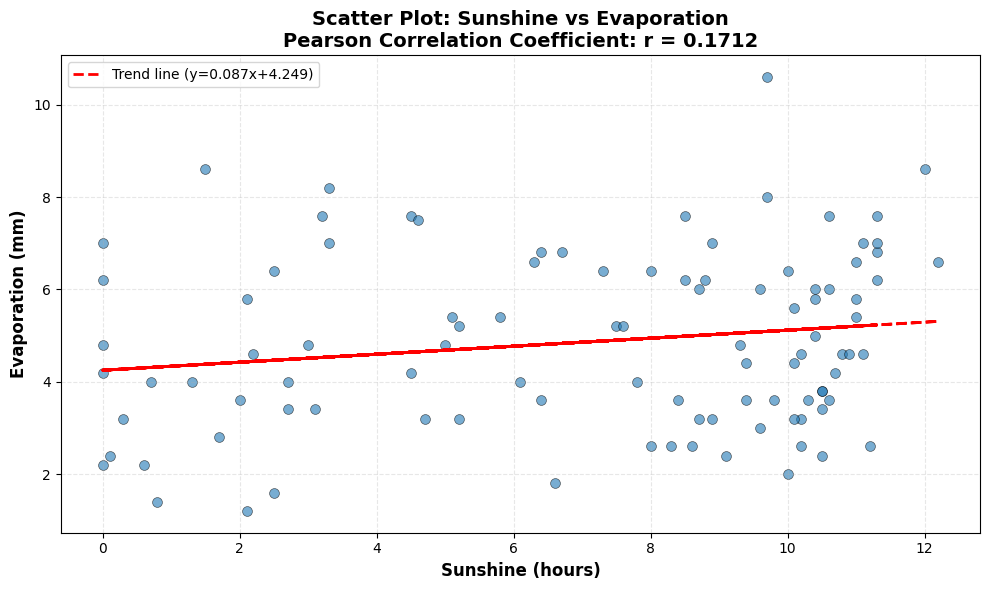


Correlation Matrix:
             Sunshine  Evaporation
Sunshine     1.000000     0.171215
Evaporation  0.171215     1.000000


In [247]:
# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(weather_data['Sunshine'], weather_data['Evaporation'], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Add trend line
z = np.polyfit(weather_data['Sunshine'], weather_data['Evaporation'], 1)
p = np.poly1d(z)
plt.plot(weather_data['Sunshine'], p(weather_data['Sunshine']), "r--", linewidth=2, label=f'Trend line (y={z[0]:.3f}x+{z[1]:.3f})')

plt.xlabel('Sunshine (hours)', fontsize=12, fontweight='bold')
plt.ylabel('Evaporation (mm)', fontsize=12, fontweight='bold')
plt.title(f'Scatter Plot: Sunshine vs Evaporation\nPearson Correlation Coefficient: r = {r:.4f}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
correlation_matrix = weather_data[['Sunshine', 'Evaporation']].corr()
print(correlation_matrix)